# Topic : Sleep, Screen Time and Stress Analysis
#### DS202 - Final Project
#### Member: Cotton, Flor, Kai, Yuna
#### Date: 2026-03-27

## Connect DataBase

In [5]:
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
conn = psycopg2.connect(
    dbname = "project-sleep",
    user = "postgres",
    password = 'VMware1!',
    host = 'localhost',
    port = '5432'
)
cur = conn.cursor()

## Create Table

In [29]:
try:
    cur.execute("""
        DROP TABLE IF EXISTS sleep_analysis;
        
        CREATE TABLE sleep_analysis(
            user_id serial PRIMARY KEY,
            age INT,
            gender VARCHAR(50),
            occupation VARCHAR(50),
            daily_screen_time_hours DOUBLE PRECISION,
            phone_usage_before_sleep_minutes DOUBLE PRECISION, 
            sleep_duration_hours DOUBLE PRECISION,
            sleep_quality_score DOUBLE PRECISION,
            stress_level DOUBLE PRECISION,
            caffeine_intake_cups INT,
            physical_activity_minutes INT,
            notifications_received_per_day INT,
            mental_fatigue_score DOUBLE PRECISION  
        );
    """)
    conn.commit()

except Exception as e:
    conn.rollback()
    print("Error occurred, transaction rolled back")
    print(e)


## Import csv file to SQL

In [30]:
try:
    cur.execute("""
    COPY sleep_analysis
    FROM 'D:\sleep_mobile_stress_dataset_15000.csv'
    DELIMITER ','
    CSV HEADER;
    """)
    conn.commit()
    
except Exception as e:
    conn.rollback()
    print("Error occurred, transaction rolled back")
    print(e)

## Check the data through "SELECT" query

In [33]:
cur.execute("""
    SELECT * FROM sleep_analysis
""")

rows = cur.fetchall()

for row in rows:
    print(row)

(1, 56, 'Female', 'Designer', 3.26, 86.0, 5.31, 7.72, 3.49, 0, 35, 119, 3.57)
(2, 46, 'Female', 'Teacher', 1.85, 32.0, 7.36, 9.7, 3.01, 0, 16, 299, 1.91)
(3, 32, 'Female', 'Designer', 3.04, 107.0, 4.5, 6.38, 5.03, 0, 17, 21, 6.05)
(4, 25, 'Male', 'Software Engineer', 9.0, 36.0, 6.68, 5.53, 10.0, 0, 3, 220, 9.92)
(5, 38, 'Female', 'Teacher', 3.52, 56.0, 7.57, 6.69, 6.71, 4, 92, 167, 5.99)
(6, 56, 'Male', 'Teacher', 7.26, 10.0, 7.79, 6.16, 10.0, 2, 50, 198, 7.85)
(7, 36, 'Female', 'Teacher', 4.56, 83.0, 6.81, 6.81, 5.38, 0, 19, 39, 5.52)
(8, 40, 'Male', 'Manager', 3.36, 89.0, 6.5, 8.75, 3.48, 2, 66, 127, 4.5)
(9, 28, 'Male', 'Student', 2.3, 109.0, 7.57, 8.05, 3.46, 3, 103, 99, 2.52)
(10, 28, 'Female', 'Manager', 9.75, 46.0, 4.73, 5.52, 10.0, 3, 56, 121, 10.0)
(11, 41, 'Male', 'Designer', 5.69, 65.0, 7.4, 5.78, 7.9, 1, 13, 86, 7.91)
(12, 53, 'Female', 'Designer', 2.03, 88.0, 8.6, 5.79, 5.23, 0, 91, 294, 3.37)
(13, 57, 'Male', 'Designer', 2.79, 3.0, 7.41, 10.0, 1.87, 3, 111, 203, 1.57)
(14

## Retrieve Data through panda

In [46]:
df = pd.read_sql("SELECT * FROM sleep_analysis", conn)

#check the tables
df.info()
row, column = df.shape

print("\n##Information##\nrow : ", row, "column : ", column, "\n")

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  object 
 3   occupation                        15000 non-null  object 
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  float64
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  ment

C:\Users\YuNa\AppData\Local\Temp\ipykernel_23024\2591482426.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM sleep_analysis", conn)


user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups                0
physical_activity_minutes           0
notifications_received_per_day      0
mental_fatigue_score                0
dtype: int64

# Visualization
### [Factors]
#### 1. Occupation, 2. Physical Activity, 
#### 3. Age Group, 
#### 4. Phone usage, 5. Caffeine intake

## 1-1. Average Stress Level by Occupation
### Purpose: Identify which occupations have the highest or lowest stress levels on average.
### Key Insight: Irregular occupation tend to be more stressful than other regular ones.

C:\Users\YuNa\AppData\Local\Temp\ipykernel_37048\1216309988.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  avg_stress_df = pd.read_sql(avg_stress_query, conn)


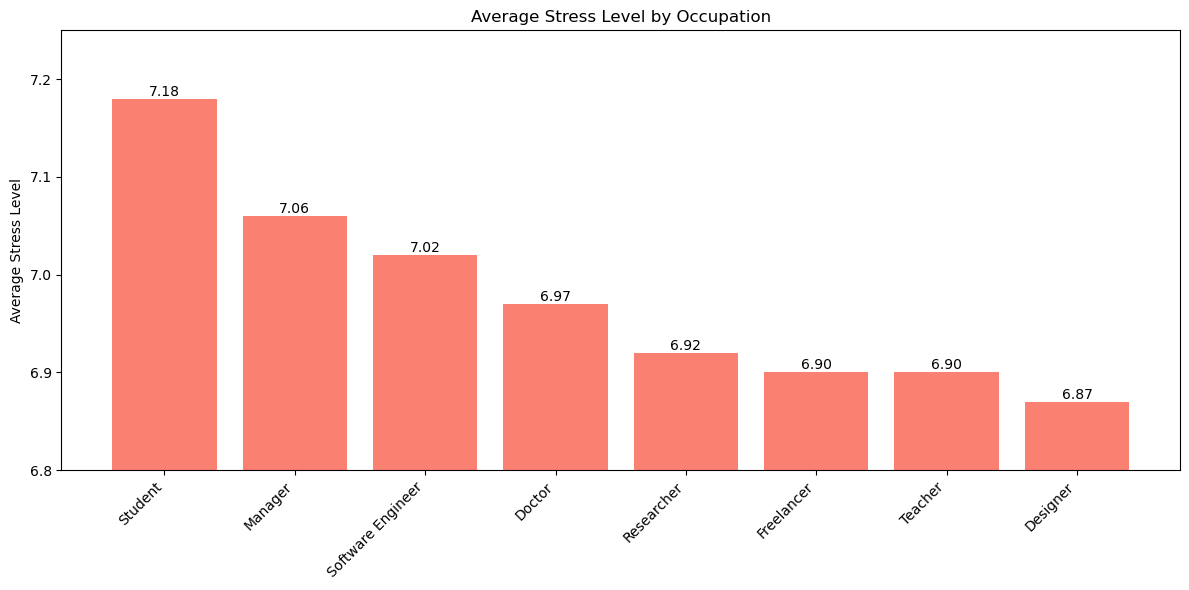

In [6]:
avg_stress_query = """
SELECT occupation, ROUND(AVG(stress_level)::numeric, 2) AS avg_stress_level
FROM sleep_analysis
GROUP BY occupation
ORDER BY avg_stress_level DESC;
"""
avg_stress_df = pd.read_sql(avg_stress_query, conn)

plt.figure(figsize=(12,6))

bars = plt.bar(avg_stress_df['occupation'], avg_stress_df['avg_stress_level'], color='salmon')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Stress Level')
plt.ylim(6.8, 7.25)
plt.title('Average Stress Level by Occupation')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )
plt.tight_layout()

plt.show()

## 1-2 Stress level & Sleep quality of student's age
### purpose: Identify stress level of student's age
### Key Insight: Age group within 18-25 showed the highest stress level

C:\Users\YuNa\AppData\Local\Temp\ipykernel_37048\2109737624.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  age_df = pd.read_sql(age_query, conn)


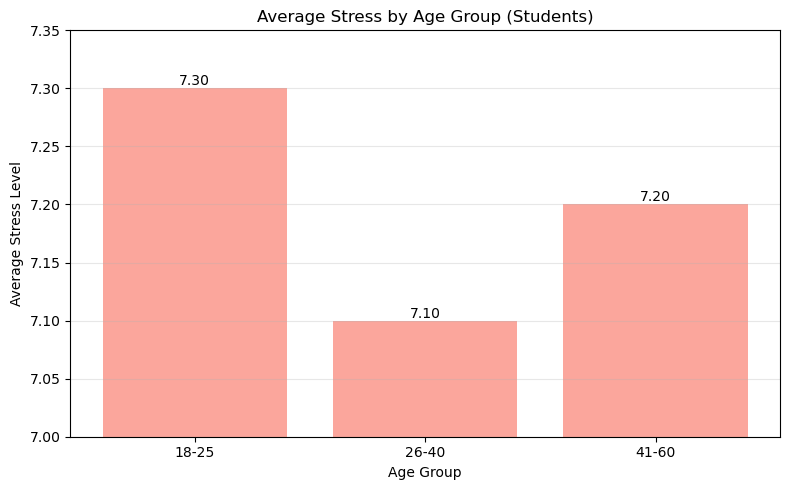

In [10]:
age_query = """
SELECT 
	CASE
		WHEN age BETWEEN 18 AND 25 THEN '18-25'
		WHEN age BETWEEN 26 AND 40 THEN '26-40'
		WHEN age BETWEEN 41 AND 60 THEN '41-60'
	END AS age_group,
	ROUND(AVG(stress_level)::numeric, 2) AS avg_stress
FROM sleep_analysis
WHERE occupation = 'Student'
GROUP BY age_group;
"""
import matplotlib.pyplot as plt

age_df = pd.read_sql(age_query, conn)

plt.figure(figsize=(8,5))

bars = plt.bar(
    age_df['age_group'],
    age_df['avg_stress'],  
    color='salmon',
    alpha=0.7
)

plt.xlabel('Age Group')
plt.ylabel('Average Stress Level')
plt.ylim(7.0, 7.35)
plt.title('Average Stress by Age Group (Students)')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

## 1-3 Average Stress Level by Occupation & Gender
### Purpose: Compare stress levels between genders within the same occupation.
### Key Insight: There's no diffences related to gender.

C:\Users\YuNa\AppData\Local\Temp\ipykernel_37048\1281937726.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  gender_stress_df = pd.read_sql(gender_stress_query, conn)


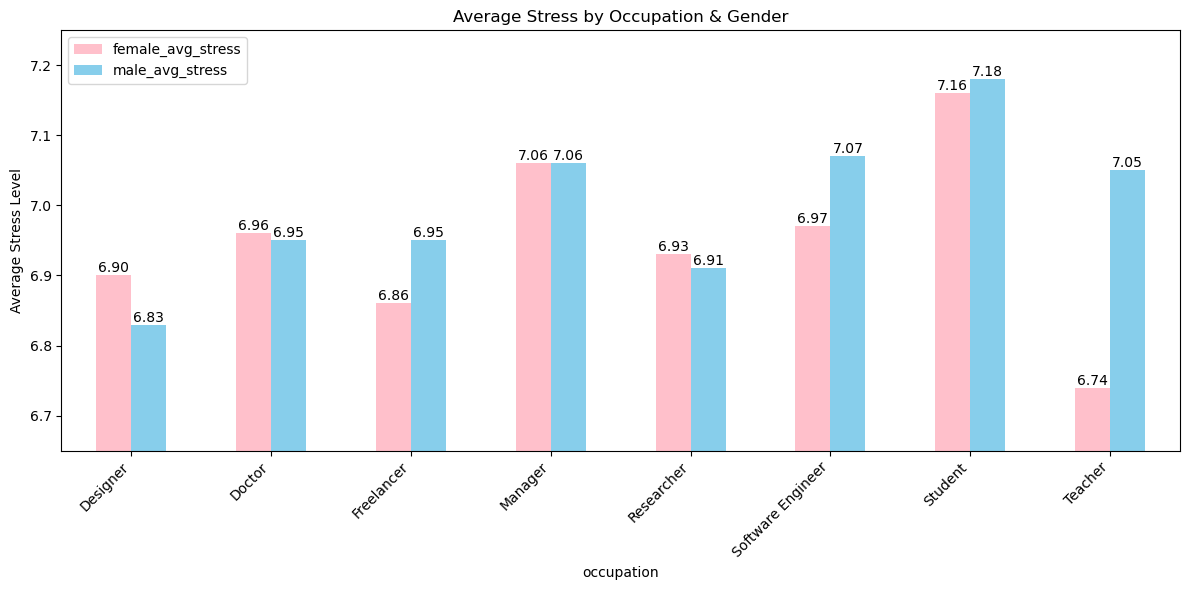

In [4]:
gender_stress_query = """
SELECT occupation,
       ROUND(AVG(CASE WHEN gender='Female' THEN stress_level END)::numeric, 2) AS female_avg_stress,
       ROUND(AVG(CASE WHEN gender='Male' THEN stress_level END)::numeric, 2) AS male_avg_stress
FROM sleep_analysis
GROUP BY occupation
ORDER BY occupation;
"""
gender_stress_df = pd.read_sql(gender_stress_query, conn)

ax = gender_stress_df.plot(x='occupation', kind='bar', figsize=(12,6), color=['pink', 'skyblue'])
plt.ylabel('Average Stress Level')
plt.ylim(6.65, 7.25)
plt.title('Average Stress by Occupation & Gender')
plt.xticks(rotation=45, ha='right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

## 1-4 Average Sleep Quality by Occupation
### Purpose: See which occupations tend to have better or worse sleep quality.
### Key Insight: Irregular occupation tend to be more stressful than other regular ones.

C:\Users\YuNa\AppData\Local\Temp\ipykernel_23024\1863544091.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sleep_df = pd.read_sql(sleep_query, conn)


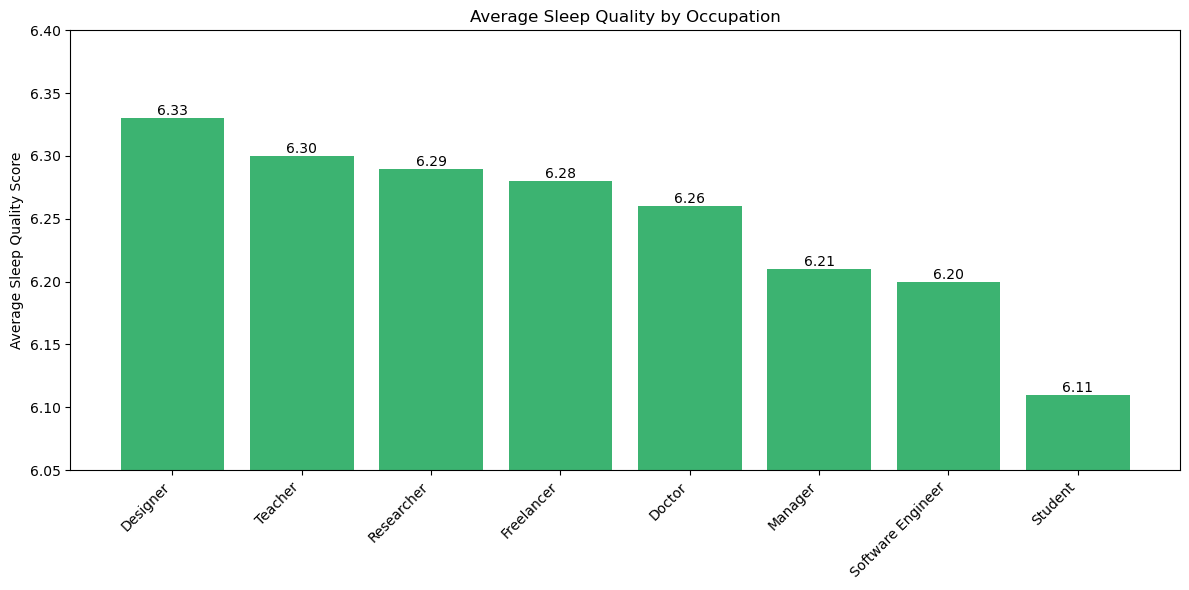

In [101]:
sleep_query = """
SELECT occupation, ROUND(AVG(sleep_quality_score)::numeric, 2) AS avg_sleep_quality_score
FROM sleep_analysis
GROUP BY occupation
ORDER BY avg_sleep_quality_score DESC;
"""
sleep_df = pd.read_sql(sleep_query, conn)

plt.figure(figsize=(12,6))
bars = plt.bar(sleep_df['occupation'], sleep_df['avg_sleep_quality_score'], color='mediumseagreen')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Sleep Quality Score')
plt.ylim(6.05, 6.4)
plt.title('Average Sleep Quality by Occupation')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )
    
plt.tight_layout()
plt.show()


## 2-1 Sleep Quality by Activity Level
### Purpose: Show how activity levels relate to stress and sleep quality simultaneously.
### Key Insight: Engaging in 30-60 minutes of physical activity help you get good-quality sleep. 

C:\Users\YuNa\AppData\Local\Temp\ipykernel_23024\2822463475.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  activity_df = pd.read_sql(activity_query, conn)


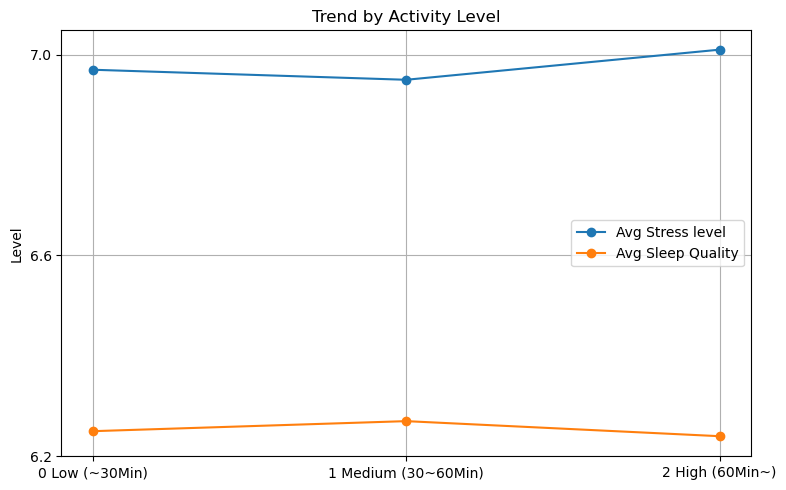

In [129]:
activity_query = """
    SELECT CASE WHEN physical_activity_minutes < 30 THEN '0 Low (~30Min)' 
    WHEN physical_activity_minutes BETWEEN 30 AND 60 THEN '1 Medium (30~60Min)' 
    ELSE '2 High (60Min~)' END AS activity_level, 
    ROUND(AVG(stress_level)::numeric, 2) AS avg_stress_level, 
    ROUND(AVG(sleep_quality_score)::numeric, 2) AS avg_sleep_quality_score 
    FROM sleep_analysis 
    GROUP BY activity_level 
    ORDER BY activity_level; """ 
activity_df = pd.read_sql(activity_query, conn)

plt.figure(figsize=(8,5))

plt.plot(
    activity_df['activity_level'],
    activity_df['avg_stress_level'],
    marker='o',
    label='Avg Stress level'
)

plt.plot(
    activity_df['activity_level'],
    activity_df['avg_sleep_quality_score'],
    marker='o',
    label='Avg Sleep Quality'
)

plt.ylabel('Level')
plt.yticks([6.2, 6.6, 7.0])
plt.title('Trend by Activity Level')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## 1,2 Average Quality by Stress level
### Purpose: Average Sleep Quality by Stress Level
### Key Insight: Irregular occupation tend to be more stressful than other regular ones.

C:\Users\YuNa\AppData\Local\Temp\ipykernel_23024\486454230.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sleep_df = pd.read_sql(
C:\Users\YuNa\AppData\Local\Temp\ipykernel_23024\486454230.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stress_sleep_avg = sleep_df.groupby('stress_bin')['sleep_quality_score'].mean().reset_index()


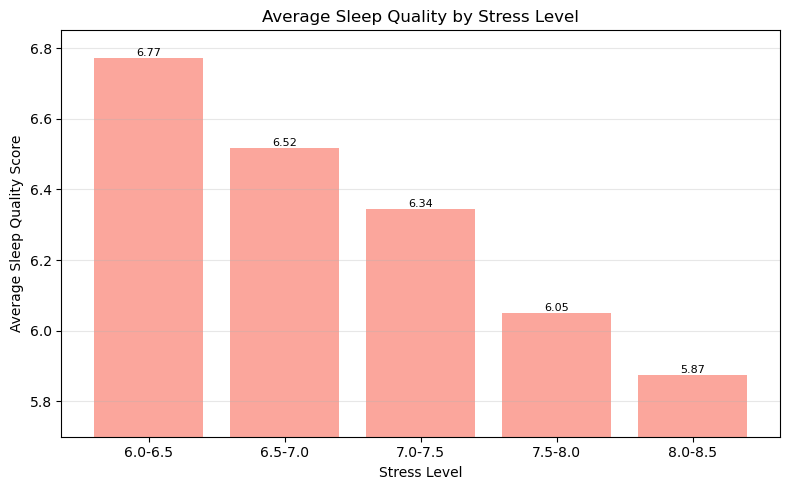

In [128]:
sleep_df = pd.read_sql(
    "SELECT sleep_duration_hours, sleep_quality_score, stress_level FROM sleep_analysis",
    conn
)

bins = [6.0, 6.5, 7.0, 7.5, 8.0, 8.5]  
labels = ['6.0-6.5','6.5-7.0','7.0-7.5','7.5-8.0','8.0-8.5']
sleep_df['stress_bin'] = pd.cut(sleep_df['stress_level'], bins=bins, labels=labels, include_lowest=True)

stress_sleep_avg = sleep_df.groupby('stress_bin')['sleep_quality_score'].mean().reset_index()

# Bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(
    stress_sleep_avg['stress_bin'],
    stress_sleep_avg['sleep_quality_score'],
    color='salmon',
    alpha=0.7
)

plt.xlabel('Stress Level')
plt.ylabel('Average Sleep Quality Score')
plt.ylim(5.7, 6.85)
plt.title('Average Sleep Quality by Stress Level')
plt.grid(axis='y', alpha=0.3)

# 라벨 추가
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.show()

## 3-1. Average Sleep Quality by Age Goup

In [ ]:
create_table_query = """
CREATE TABLE sleep_data (
    id SERIAL PRIMARY KEY,
    age INT,
    sleep_duration_hours FLOAT,
    sleep_quality_score FLOAT,
    stress_level INT,
    occupation VARCHAR(50)
);
"""

cur.execute(create_table_query)
conn.commit()

In [11]:
import seaborn as sns

sns.set_theme(style="whitegrid")

df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 25, 40, 60, 100],
    labels=['Under 18', '18-25', '26-40', '41-60', '60+'],
    right=False
)

order = ['Under 18', '18-25', '26-40', '41-60', '60+']



## Average Sleep Quanlity by Age Group

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='age_group',
    y='sleep_quality_score',
    order=order
)

plt.title('Average Sleep Quality by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Sleep Quality')
plt.show()

## 3-2. Average Sleep Duration by Age Group

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='age_group',
    y='sleep_duration_hours',
    order=order
)

plt.title('Average Sleep Duration by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Hours of Sleep')
plt.show()

## 3-3. Average Stress Level by Age Group

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='age_group',
    y='stress_level',
    order=order
)

plt.title('Average Stress Level by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Stress Level')
plt.show()

# 4. Do individuals with higher phone usage before sleep consistently report lower sleep quality?

You are trying to determine:

* Whether screen exposure before sleep affects sleep quality
* If there is a consistent negative trend
* How increasing phone usage before sleep influences overall sleep quality
* If individuals with minimal phone usage consistently report better sleep quality

Data to Use:
* phone_usage_before_sleep_minutes
* sleep_quality_score

# 4-1 Do individuals with higher phone usage before sleep consistently report lower sleep quality?

You are trying to determine:

* Whether screen exposure before sleep affects sleep quality
* If there is a consistent negative trend
* How increasing phone usage before sleep influences overall sleep quality
* If individuals with minimal phone usage consistently report better sleep quality

Data to Use:
* phone_usage_before_sleep_minutes
* sleep_quality_score

In [ ]:
query = """
SELECT 
    phone_usage_before_sleep_minutes,
    AVG(sleep_quality_score) AS avg_sleep_quality
FROM sleep_analysis
GROUP BY phone_usage_before_sleep_minutes
ORDER BY phone_usage_before_sleep_minutes;
"""

slp_phone = pd.read_sql(query, conn)

plt.figure(figsize=(9, 5))
plt.plot(slp_phone['phone_usage_before_sleep_minutes'],
         slp_phone['avg_sleep_quality'], color='purple')

plt.title('Phone Usage Before Sleep vs Sleep Quality', fontsize=15, pad=10)
plt.xlabel('Phone Usage Before Sleep (minutes)')
plt.xlim(0, 120)
plt.ylabel('Average Sleep Quality Score')
plt.grid(linestyle='--', alpha=0.5)

plt.show()

# 5. What is the relationship between caffeine intake (cups per day) and sleep quality score?
You are trying to determine:

* If higher caffeine consumption reduces sleep quality
* How sleep quality changes across different levels of caffeine consumption
* At what point caffeine consumption begins to significantly impact sleep quality

Data to Use:

* caffeine_intake_cups
* sleep_quality_score

In [ ]:
query_group = """
SELECT 
    CASE 
        WHEN caffeine_intake_cups <= 1 THEN 'Low'
        WHEN caffeine_intake_cups BETWEEN 2 AND 3 THEN 'Moderate'
        ELSE 'High'
    END AS caffeine_group,
    AVG(sleep_quality_score) AS avg_sleep_quality
FROM sleep_analysis
GROUP BY caffeine_group;
"""

slp_group = pd.read_sql(query_group, conn)
slp_group

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(slp_group['caffeine_group'], slp_group['avg_sleep_quality'], color = 'purple')
slp_group = slp_group.set_index('caffeine_group').loc[['Low', 'Moderate', 'High']].reset_index()
plt.title('Sleep Quality by Caffeine Consumption Level', fontsize=15, pad=10)
plt.xlabel('Caffeine Consumption By Group')
plt.ylabel('Average Sleep Quality')

plt.show()

In [ ]:
query_group = """
SELECT 
    CASE 
        WHEN caffeine_intake_cups <= 1 THEN 'Low'
        WHEN caffeine_intake_cups BETWEEN 2 AND 3 THEN 'Moderate'
        ELSE 'High'
    END AS caffeine_group,
    AVG(sleep_quality_score) AS avg_sleep_quality
FROM sleep_analysis
GROUP BY caffeine_group;
"""

slp_group = pd.read_sql(query_group, conn)
slp_group

plt.figure(figsize=(9, 5))

plt.bar(slp_group['caffeine_group'], slp_group['avg_sleep_quality'], color = 'purple')
slp_group = slp_group.set_index('caffeine_group').loc[['Low', 'Moderate', 'High']].reset_index()
plt.title('Sleep Quality by Caffeine Consumption Level', fontsize=15, pad=10)
plt.xlabel('Caffeine Consumption By Group')
plt.ylabel('Average Sleep Quality')

plt.show()